In [ ]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import netCDF4 as nc
from glob import glob
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, FuncFormatter
print('done')

done


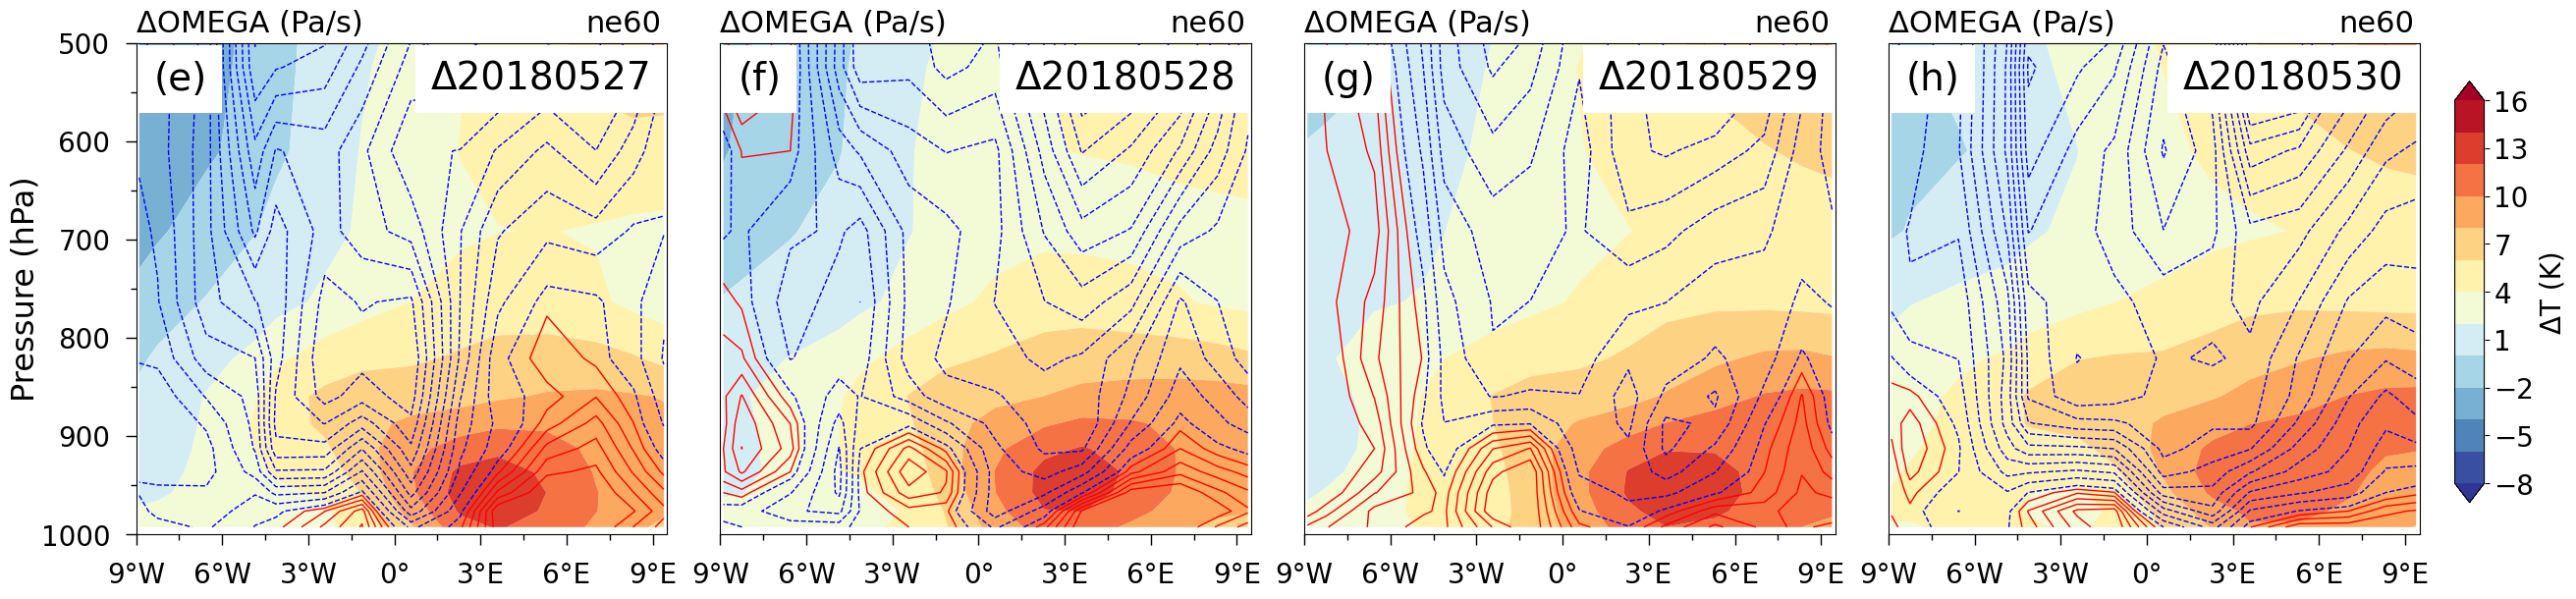

In [ ]:

base_dir = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist"
date_list = ['2018-05-27', '2018-05-28', '2018-05-29', '2018-05-30']
lat0, dlat = 51, 0.25
lon_min, lon_max = -9, 9.5
n = 2

base_file = f"{base_dir}/MUSICAv0_ne60_production.cam.h3.2018-05-20-00000.nc"
ds_base = xr.open_dataset(base_file)

lat = ds_base['lat'].values
lon = ds_base['lon'].values
lev = ds_base['lev'].values
idx_lat = np.where(np.abs(lat - lat0) <= dlat)[0]
lon_ = lon.copy()
lon_[lon_ > 180] -= 360
idx_lon = np.where((lon_[idx_lat] >= lon_min) & (lon_[idx_lat] <= lon_max))[0]
idx_sel = idx_lat[idx_lon]
lon_sel = lon_[idx_sel]
sorter = np.argsort(lon_sel)
lon_sel = lon_sel[sorter]

fig, axes = plt.subplots(1, 4, figsize=(30, 6.5))
axes = axes.flatten()
for i, date_str in enumerate(date_list):
    file_nc = f"{base_dir}/MUSICAv0_ne60_production.cam.h3.{date_str}-00000.nc"
    ds = xr.open_dataset(file_nc)
    
    T_diff = ds['T'][0, :, :].values - ds_base['T'][0, :, :].values
    OMEGA_diff = (ds['OMEGA'][0, :, :].values - ds_base['OMEGA'][0, :, :].values) * 100
    T_sel = T_diff[:, idx_sel][:, sorter]
    OMEGA_sel = OMEGA_diff[:, idx_sel][:, sorter]

    N = len(lon_sel)
    idx_sparse = np.concatenate(([0], np.arange(1, N-1, n), [N-1]))
    lon_sel_sparse   = lon_sel   [idx_sparse]
    T_sel_sparse     = T_sel     [:, idx_sparse]
    OMEGA_sel_sparse = OMEGA_sel [:, idx_sparse]
    OMEGA_sel_sparse = np.clip(OMEGA_sel_sparse, -41, 5)
    Lon, Lev = np.meshgrid(lon_sel_sparse, lev)
    T_smooth = gaussian_filter(T_sel_sparse, sigma=0.6)

    ax = axes[i]
    temp_levels = np.arange(-8, 17, 2)
    cf = ax.contourf(
        Lon, Lev, T_smooth,
        levels=temp_levels,
        cmap='RdYlBu_r', extend='both', antialiased=True
    )

    neg_levels = np.arange(-41, 0, 2)
    pos_levels = np.arange(0, 5, 1)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=neg_levels,
               colors='b', linestyles='dashed', linewidths=1)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=pos_levels,
               colors='r', linestyles='solid', linewidths=1)

    xticks = np.arange(np.ceil(lon_min), np.floor(lon_max)+1, 3)
    xticklabels = []
    for val in xticks:
        if val < 0:
            xticklabels.append(f"{int(-val)}°W")
        elif val > 0:
            xticklabels.append(f"{int(val)}°E")
        else:
            xticklabels.append('0°')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=20)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=20, pad=12, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1 )
    ax.set_xlim(lon_min, lon_max)
    ax.invert_yaxis()
    ax.set_ylim(1000, 500)
    ax.tick_params(axis='y', labelsize=15)
    
    if i == 0:
        ax.set_ylabel("Pressure (hPa)", fontsize=23, labelpad=0.5)
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=11, length=8, width=1 )
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1 )
    elif i == 3:
        ax.set_ylabel("", fontsize=20, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=12, length=8, width=1, labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1, labelleft=False, labelright=False, left=False, right=False)
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

    ax.text(0.0, 1.01, 'ΔOMEGA (Pa/s)', fontsize=22,
            ha='left', va='bottom', transform=ax.transAxes)
    ax.text(0.99, 1.01, r'ne60', fontsize=22,
            ha='right', va='bottom', transform=ax.transAxes)
    ax.text(0.033, 0.965, f'({chr(ord("e") + i)})',
            fontsize=28, va='top', ha='left', transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.4'))
    day = 27 + i
    ax.text(0.97, 0.965, f"Δ201805{day:02d}",
            fontsize=28, va='top', ha='right', transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.4'))
    
cax = fig.add_axes([0.912, 0.16, 0.01, 0.66])  
cbar = fig.colorbar(
    cf,
    cax=cax,
    orientation='vertical',
    shrink=0.85,
    ticks=np.arange(-8, 18, 3),
    aspect=18,
    extend='both'
)
cbar.set_label('ΔT (K)', fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.subplots_adjust(wspace=0.1, hspace=0.28)

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"
def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.0f}°N"
    else:
        return f"{abs(y):.0f}°S"

for _ax in axes:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    # _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))


In [3]:
print('OMEGA max:', np.nanmax(OMEGA_sel_sparse))
print('OMEGA min:', np.nanmin(OMEGA_sel_sparse))

OMEGA max: 5.0
OMEGA min: -41.0
